
 TASK 2: Exploratory Data Analysis (EDA)

Ask meaningful questions about the dataset before analysis.

Explore the data structure, including variables and data types.

Identify trends, patterns and anomalies within the data.

Test hypotheses and validate assumptions using statistics and visualization.

Detect potential data issues or problems to address in further analysis.

In [ ]:
from collections import Counter
import re
import json

In [ ]:
df = pd.DataFrame(dataapp_df)
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,f6ef6d49-ebfa-4e3e-8ddc-62a33d4c4402,Agbeni Blessing,https://play-lh.googleusercontent.com/a/ACg8oc...,this app they are thief I send 3k into my acco...,1,0,1.0.0,2025-11-02 16:13:04,None,None,1.0.0
1,85b47540-b784-49d0-9e1d-db5ad7f48840,Olanike Ayandeyi,https://play-lh.googleusercontent.com/a/ACg8oc...,they are scammers run away from them. I funded...,1,3,1.0.3,2025-10-26 20:45:41,None,None,1.0.3
2,fd468a10-2b6e-4f83-8808-d0d657373a8d,Antibas Yakubu,https://play-lh.googleusercontent.com/a-/ALV-U...,"Your networking is bad, and it doesn't seem li...",2,0,1.0.3,2025-10-25 17:16:23,None,None,1.0.3
3,9a85b1e2-a9d0-4343-9ac4-b82414ff0359,Joshua Mordi,https://play-lh.googleusercontent.com/a-/ALV-U...,since I upgraded this app I can't even login a...,1,0,1.0.3,2025-10-23 10:05:53,None,None,1.0.3
4,1bc93749-4060-4a51-9311-b645f17a111a,Asainze Ernest,https://play-lh.googleusercontent.com/a-/ALV-U...,Very poor application,1,0,1.0.3,2025-10-21 06:15:56,None,None,1.0.3
...,...,...,...,...,...,...,...,...,...,...,...
56,84d07e48-eb21-4fb7-a0d7-09343bd414dd,NURA LAWAL,https://play-lh.googleusercontent.com/a-/ALV-U...,I have downloaded the app but I find it hard t...,1,7,1.0.0,2024-11-29 09:06:05,None,None,1.0.0
57,07aed132-89d7-48eb-8431-40ac3a4b4305,Abba Nasir,https://play-lh.googleusercontent.com/a/ACg8oc...,Data is good,5,4,None,2024-11-04 12:32:41,None,None,None
58,20762a82-026b-41e2-893a-196fcd0c9f43,Bello Abdullahi,https://play-lh.googleusercontent.com/a-/ALV-U...,Convenient and Reliable! DataApp has made life...,5,71,1.0.0,2024-11-03 02:14:09,None,None,1.0.0
59,38389945-88e9-4a68-870d-5a7f35e4958e,Abba Yakubu,https://play-lh.googleusercontent.com/a/ACg8oc...,We Love DataApp,5,16,1.0.0,2024-11-02 19:29:47,None,None,1.0.0


In [ ]:
# Preview data
print("First 5 rows:\n", df.head())

First 5 rows:
                                reviewId          userName  \
0  f6ef6d49-ebfa-4e3e-8ddc-62a33d4c4402   Agbeni Blessing   
1  85b47540-b784-49d0-9e1d-db5ad7f48840  Olanike Ayandeyi   
2  fd468a10-2b6e-4f83-8808-d0d657373a8d    Antibas Yakubu   
3  9a85b1e2-a9d0-4343-9ac4-b82414ff0359      Joshua Mordi   
4  1bc93749-4060-4a51-9311-b645f17a111a    Asainze Ernest   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8oc...   
1  https://play-lh.googleusercontent.com/a/ACg8oc...   
2  https://play-lh.googleusercontent.com/a-/ALV-U...   
3  https://play-lh.googleusercontent.com/a-/ALV-U...   
4  https://play-lh.googleusercontent.com/a-/ALV-U...   

                                             content  score  thumbsUpCount  \
0  this app they are thief I send 3k into my acco...      1              0   
1  they are scammers run away from them. I funded...      1              3   
2  Your networking is bad, and it doesn't seem 

In [ ]:
#Explore data structure

print("\nData Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe(include='all'))


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              61 non-null     object        
 1   userName              61 non-null     object        
 2   userImage             61 non-null     object        
 3   content               61 non-null     object        
 4   score                 61 non-null     int64         
 5   thumbsUpCount         61 non-null     int64         
 6   reviewCreatedVersion  49 non-null     object        
 7   at                    61 non-null     datetime64[ns]
 8   replyContent          0 non-null      object        
 9   repliedAt             0 non-null      object        
 10  appVersion            49 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 5.4+ KB
None

Summary Statistics:
                                    

In [ ]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
reviewId                 0
userName                 0
userImage                0
content                  0
score                    0
thumbsUpCount            0
reviewCreatedVersion    12
at                       0
replyContent            61
repliedAt               61
appVersion              12
dtype: int64


In [ ]:
# Convert review date to datetime
df['at'] = pd.to_datetime(df['at'])

In [ ]:
# Reviews over time (monthly)
reviews_per_month = df.groupby(df['at'].dt.to_period("M")).size()
print("\nReviews per month:\n", reviews_per_month)


Reviews per month:
 at
2024-11     6
2024-12     1
2025-01    12
2025-02    14
2025-03     4
2025-04     2
2025-05     1
2025-07     3
2025-08     2
2025-09     5
2025-10    10
2025-11     1
Freq: M, dtype: int64


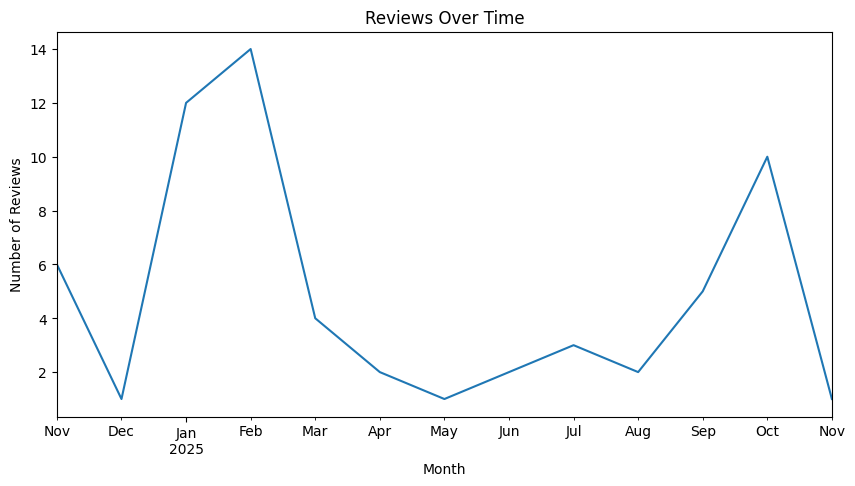

In [ ]:
# Plot reviews over time
reviews_per_month.plot(kind='line', figsize=(10,5))
plt.title("Reviews Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

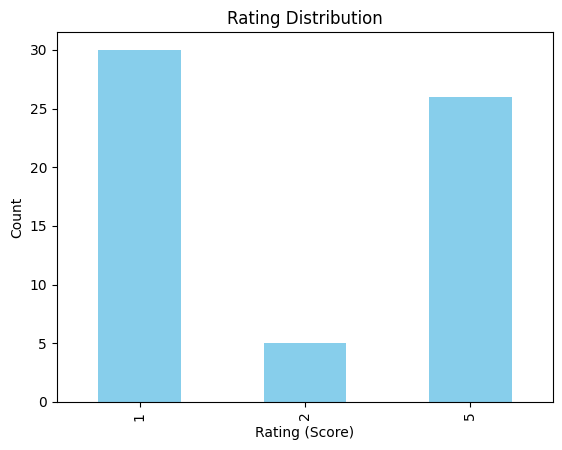

In [ ]:
# Rating distribution
df['score'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Rating Distribution")
plt.xlabel("Rating (Score)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Average rating per appVersion
avg_score_version = df.groupby('appVersion')['score'].mean().sort_values()
print("\nAverage Rating per App Version:\n", avg_score_version)


Average Rating per App Version:
 appVersion
1.0.3    1.250000
1.0.0    2.658537
1.0.2    3.000000
Name: score, dtype: float64


In [ ]:
# Duplicate reviews
print("\nDuplicate reviews:", df.duplicated().sum())


Duplicate reviews: 0


In [ ]:
# Reviews with empty content
empty_reviews = df[df['content'].isnull() | (df['content'].str.strip() == "")]
print("Number of empty reviews:", len(empty_reviews))

Number of empty reviews: 0


In [ ]:
# Combine all review content
all_text = " ".join(df['content'].dropna().astype(str))

In [ ]:
# Clean text
all_text = re.sub(r"[^A-Za-z\s]", "", all_text).lower()
words = [w for w in all_text.split() if len(w) > 3]  # remove short words

In [ ]:
# Count common words
common_words = Counter(words).most_common(20)
print("\nMost common words in reviews:")
for word, count in common_words:
    print(word, ":", count)


Most common words in reviews:
this : 22
money : 18
they : 17
data : 17
good : 11
account : 10
cant : 10
very : 9
your : 9
have : 9
even : 8
dataapp : 8
useless : 7
about : 7
love : 7
just : 7
scam : 7
funded : 5
their : 5
customer : 5


In [ ]:
# Hypothesis: Longer reviews get more thumbs-up
df['content_length'] = df['content'].astype(str).apply(len)
correlation = df['content_length'].corr(df['thumbsUpCount'])
print("\nCorrelation between review length and thumbsUpCount:", correlation)


Correlation between review length and thumbsUpCount: 0.4675205053188183


In [ ]:
# Hypothesis: Negative reviews receive more developer replies
negative_reviews = df[df['score'] <= 2]
reply_rate_negative = negative_reviews['replyContent'].notnull().mean()
positive_reviews = df[df['score'] >= 4]
reply_rate_positive = positive_reviews['replyContent'].notnull().mean()
print("\nReply rate for negative reviews:", reply_rate_negative)
print("Reply rate for positive reviews:", reply_rate_positive)


Reply rate for negative reviews: 0.0
Reply rate for positive reviews: 0.0
